# 05 · ¿Cuánto dinero, dónde y cuándo? Reparto del presupuesto
**Torre del Caribe** · Fase 6 (Investigación de Operaciones) · Autor: **Brandon Uriel García Sánchez** · UNRC, LCDN 5° semestre 2026-2

| | |
|---|---|
| **Qué hace** | Reparte el presupuesto entre meses, los 3 lugares del sur y dos canales (Google, Facebook) para traer el máximo de visitantes sin rebasar la capacidad de nadie. |
| **Decisiones de Brandon** | Objetivo: visitantes al sur · presupuesto $250,000 al año (supuesto) · conversión de Facebook con barrido · cero anuncio en temporada alta, capacidad probada, piso de 15 % por lugar y tope de 70 % por canal · desempate proporcional al espacio libre (`docs/decisiones/19-presupuesto.md`). |
| **Código** | `backend/torre/campana/presupuesto.py` (PuLP + CBC). |
| **Ecuaciones** | `docs/metodologia/ECUACIONES.md` §4. |
| **Alimenta a** | El plan de medios de la campaña (Fase 8) y las pausas que ejecuta la Torre en vivo (Fase 7). |

In [1]:
%matplotlib inline
import sys, warnings
from dataclasses import replace
from pathlib import Path
warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "backend"))

import pandas as pd
import matplotlib.pyplot as plt
from torre.campana import presupuesto as pz
from torre.documento.figuras import estilo_unrc, GUINDA, DORADO, GRIS_TEXTO
pd.set_option("display.max_colwidth", 60)
estilo_unrc()

## 1. Los parámetros, todos de archivos
- **Costo por clic y conversión** de la categoría *Travel* (WordStream 2025, capturado en la Fase 1, D13). Son promedios
  de anunciantes de EE. UU.: se usan como supuesto etiquetado.
- **Conversión de Facebook para turismo:** no está publicada. El caso base usa la de Google Travel (5.75 %) y la
  sensibilidad prueba 3 % y la mediana de Facebook en todas las industrias.
- **Pesos por dólar:** FRED, último mes completo.
- **Meses:** los que tienen calendario (temporada) y escenarios del Monte Carlo (Fase 5) para los 3 lugares.

In [2]:
b = pz.benchmarks(); tc, mes_tc = pz.pesos_por_dolar()
ch = pz.canales(pz.Supuestos())
print(f"Pesos por dólar: {tc:.4f} ({mes_tc})")
for c, v in ch.items():
    r = v['cvr'] / v['cpc_mxn']
    print(f"{c:9s} clic = ${v['cpc_mxn']:.2f} MXN · conversión {v['cvr']:.2%} · r = {v['cvr']:.4f} ÷ {v['cpc_mxn']:.2f} = {r*1000:.2f} por cada $1,000")
t = pz.tabla_meses()
t[["periodo", "lugar", "nivel", "probable_p50_est", "bueno_p90_est", "capacidad_probada", "libre"]].round(3)

Pesos por dólar: 17.0609 (2026-08-01)
Google    clic = $36.17 MXN · conversión 5.75% · r = 0.0575 ÷ 36.17 = 1.59 por cada $1,000
Facebook  clic = $8.70 MXN · conversión 5.75% · r = 0.0575 ÷ 8.70 = 6.61 por cada $1,000


,periodo,lugar,nivel,probable_p50_est,bueno_p90_est,capacidad_probada,libre
0,2026-10-01,Bahía Calderitas–Oxtankah,tranquila,710.530,899.165,1639.0,0.566
1,2026-10-01,Chetumal,normal,54189.530,59544.787,65792.0,0.176
2,2026-10-01,Ruta arqueológica del sur,tranquila,3688.045,4724.506,10465.0,0.648
3,2026-11-01,Bahía Calderitas–Oxtankah,tranquila,709.378,901.978,1639.0,0.567
4,2026-11-01,Chetumal,normal,55758.911,60919.914,65792.0,0.152
5,2026-11-01,Ruta arqueológica del sur,tranquila,5488.230,6916.239,10465.0,0.476
6,2026-12-01,Bahía Calderitas–Oxtankah,alta,1394.589,1643.874,1639.0,0.149
7,2026-12-01,Chetumal,alta,63068.835,69008.953,65792.0,0.041
8,2026-12-01,Ruta arqueológica del sur,alta,7376.735,9276.996,10465.0,0.295
9,2027-01-01,Bahía Calderitas–Oxtankah,alta,1211.910,1446.528,1639.0,0.261


## 2. El modelo de dos etapas
**Etapa 1** (se decide hoy): $x_{m,l,c}\ge0$, pesos en el mes $m$, lugar $l$ y canal $c$. Conversiones
$v_{m,l}=\sum_c r_c\,x_{m,l,c}$.

**Etapa 2** (recurso, por escenario $s\in\{$malo, probable, bueno$\}$ con pesos 30/40/30): $y_{s,m,l}\in\{0,1\}$
enciende o pausa el anuncio; si $D_{s,m,l}+v_{m,l}>C_l$ el anuncio se pausa y esas conversiones se pierden.

$$\max\ \sum_s p_s\sum_{m,l} w_{s,m,l}\quad\text{s. a.}\quad w\le v,\ w\le U\,y,\ D_{s}+v\le C+M(1-y)$$
$$\sum x\le B,\quad x_{m,l,\cdot}=0\ \text{en temporada alta},\quad D^{p50}_{m,l}+v_{m,l}\le C_l,\quad
\sum_{m,c}x_{m,l,c}\ge0.15B,\quad \sum_{m,l}x_{m,l,c}\le0.70B$$

Paso 2 (desempate, lexicográfico): con el mismo máximo de visitantes, se minimiza $\sum|x-\text{meta}|$ con
meta $=\dfrac{\text{libre}_{m,l}}{\sum\text{libre}}\times$ total del canal, y libre $=1-D^{p50}/C$.

In [3]:
sol = pz.resolver()
print(f"Presupuesto del periodo: ${sol['presupuesto']:,.0f} ({len(sol['meses'])} meses × $250,000 ÷ 12)")
print(f"Visitantes esperados: {sol['visitantes_esperados']:,.1f} → ${sol['presupuesto']/sol['visitantes_esperados']:,.0f} por visitante")
print(f"Meses permitidos: {sum(sol['permitida'].values())} de {len(sol['permitida'])}; pausas donde hay dinero: {len(sol['pausas'].query('encendido == 0'))}")
sol["plan"].pivot_table(index="periodo", columns="lugar", values="pesos", aggfunc="sum").round(0)

Presupuesto del periodo: $187,500 (9 meses × $250,000 ÷ 12)
Visitantes esperados: 956.8 → $196 por visitante
Meses permitidos: 20 de 27; pausas donde hay dinero: 0


lugar,Bahía Calderitas–Oxtankah,Chetumal,Ruta arqueológica del sur
periodo,,,
2026-10-01,13276.0,4133.0,15177.0
2026-11-01,13293.0,3574.0,11145.0
2026-12-01,0.0,0.0,0.0
2027-01-01,0.0,5650.0,0.0
2027-02-01,9300.0,6916.0,9123.0
2027-03-01,7863.0,4209.0,0.0
2027-04-01,0.0,3821.0,10675.0
2027-05-01,11610.0,6141.0,15608.0
2027-06-01,13833.0,6091.0,16061.0


**Ejemplo a mano.** Como Facebook rinde más por peso, se lleva su tope (70 %) y el resto va a Google:
$0.70\times187{,}500\times0.006608+0.30\times187{,}500\times0.001590=867.3+89.4=956.8$ visitantes.

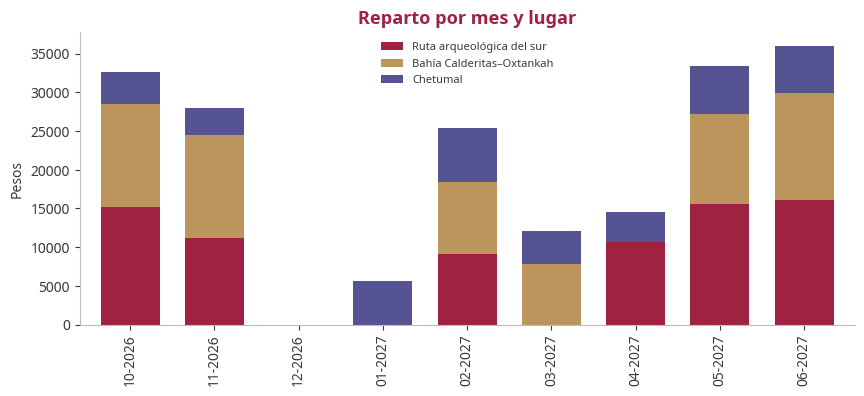

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.8))
tabla = sol["plan"].pivot_table(index="periodo", columns="lugar", values="pesos", aggfunc="sum")
tabla.index = [f"{p:%m-%Y}" for p in tabla.index]
tabla[["Ruta arqueológica del sur", "Bahía Calderitas–Oxtankah", "Chetumal"]].plot.bar(stacked=True, ax=ax,
    color=[GUINDA, DORADO, "#565393"], width=0.7)
ax.set_ylabel("Pesos"); ax.set_title("Reparto por mes y lugar"); ax.legend(frameon=False, fontsize=8)
plt.show()

## 3. ¿Cuánto cuesta cada regla?
Se resuelve el modelo sin la regla y se compara. Además, el **precio sombra** (del LP con las $y$ fijas) dice cuántos
visitantes trae un peso más de holgura en esa regla.

In [5]:
display(pz.costo_de_reglas().round(2))
pz.precios_sombra(pz.resolver()).assign(por_cada_mil=lambda d: d.precio_sombra * 1000).round(4)

,regla,visitantes_con_regla,visitantes_sin_regla,costo_visitantes,costo_pct
0,Cero anuncio en temporada alta,956.78,956.78,0.0,0.00
1,Tope de capacidad probada,956.78,956.78,0.0,0.00
2,Piso de equidad de 15 % por lugar,956.78,956.78,0.0,0.00
3,Tope de 70 % por canal,956.78,1239.07,282.3,29.51


,regla,precio_sombra,holgura,por_cada_mil
0,presupuesto,0.0016,-0.0,1.5898
1,equidad_0,-0.0000,-0.0,-0.0000
2,equidad_1,-0.0000,-28125.0,-0.0000
3,equidad_2,-0.0000,-75000.0,-0.0000
4,canal_Google,-0.0000,75000.0,-0.0000
5,canal_Facebook,0.0050,-0.0,5.0186


## 4. Frontera de Pareto: visitantes contra espacio libre
$\varepsilon$-restricción: ningún mes con anuncio puede pasar de $\varepsilon$ veces su capacidad probada en el
escenario probable.

,ocupacion_max,estado,visitantes_esperados,lugares_sin_meses
0,1.00,Optimal,956.775973,None
1,0.90,Optimal,956.775973,None
2,0.80,Optimal,956.775973,None
3,0.70,Optimal,956.775981,Chetumal
4,0.60,Optimal,956.775983,Chetumal
5,0.50,Optimal,956.775980,Chetumal
6,0.45,Optimal,956.775988,Chetumal
7,0.40,Optimal,956.775990,"Chetumal, Bahía Calderitas–Oxtankah"
8,0.35,Optimal,536.867740,"Chetumal, Bahía Calderitas–Oxtankah"
9,0.30,Optimal,0.000000,"Chetumal, Bahía Calderitas–Oxtankah, Ruta arqueológica d..."


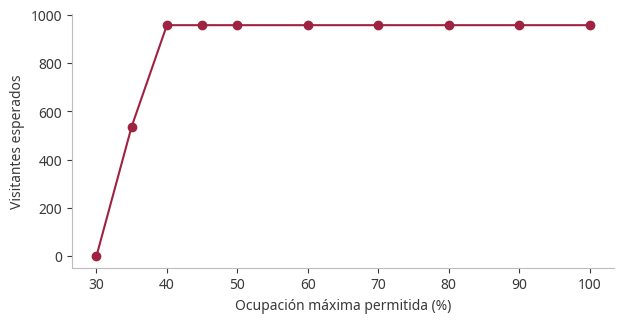

In [6]:
par = pz.pareto(); display(par)
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.plot(par.ocupacion_max * 100, par.visitantes_esperados, marker="o", color=GUINDA)
ax.set_xlabel("Ocupación máxima permitida (%)"); ax.set_ylabel("Visitantes esperados"); plt.show()

## 5. Sensibilidad: ¿qué pasa si los supuestos están mal?

In [7]:
pz.sensibilidad().round(1)

,caso,presupuesto_periodo,visitantes_esperados,pesos_por_visitante,pct_Chetumal,pct_Bahía Calderitas–Oxtankah,pct_Ruta arqueológica del sur,pct_Google,pct_Facebook,pausas_en_escenarios
0,Base,187500.0,956.8,196.0,21.6,36.9,41.5,30.0,70.0,0
1,Conversión Facebook 3 %,187500.0,542.0,346.0,21.6,36.9,41.5,30.0,70.0,0
2,Conversión Facebook 6.38% (mediana de industrias),187500.0,1051.8,178.3,21.6,36.9,41.5,30.0,70.0,0
3,Clic de Facebook a $0.42 (LocaliQ 2026),187500.0,1142.6,164.1,21.6,36.9,41.5,30.0,70.0,0
4,Golpe de tormenta 25 %,187500.0,956.8,196.0,22.0,36.8,41.2,30.0,70.0,0
5,Golpe de tormenta 50 %,187500.0,956.8,196.0,21.9,36.9,41.2,30.0,70.0,0
6,"Presupuesto $500,000 al año",375000.0,1913.6,196.0,21.6,36.9,41.5,30.0,70.0,0
7,"Presupuesto $1,000,000 al año",750000.0,3827.1,196.0,21.6,36.9,41.5,30.0,70.0,0


## 6. Qué se concluye
1. **Con $250,000 al año la campaña trae unos 957 visitantes** en los 9 meses con pronóstico (≈ $196 por visitante).
   Con conversión de Facebook de 3 %, 542; con la mediana de industrias, 1,052.
2. **Las reglas ambientales no cuestan visitantes a esta escala:** temporada alta, capacidad y equidad cuestan 0. La
   campaña es chica frente al espacio que hay. La única regla que cuesta es el tope por canal (−29.5 %), y es una
   decisión de riesgo (no depender de una sola plataforma), no de sustentabilidad.
3. **Se puede prometer más espacio sin perder visitantes:** ningún mes con anuncio pasa del 40 % de su capacidad
   probada, y los visitantes no cambian. Por debajo de 40 % la frontera cae (35 % → 537; 30 % → 0).
4. **El reparto no depende del supuesto de tormentas** (golpe 0/25/50 %): los meses con riesgo ya están fuera.
5. **Limitaciones declaradas:** costos de EE. UU.; conversión de Facebook supuesta; cada conversión cuenta como un
   visitante (cota alta); sin dato de cómo se agota la audiencia (por eso el desempate proporcional); el plan cubre
   oct-2026 a jun-2027 porque después no hay pronóstico.